**1. DATA COLLLECTION AND IMPORT**
The dataset used in this project contains flight details such as airline, source, destination, duration, and ticket price.
The dataset was provided in CSV format and imported into the Python environment using the Pandas library for further analysis.

In [6]:
# ===============================
# 1. Data Collection and Import
# ===============================

import pandas as pd
import numpy as np

# Upload file (for Google Colab)
from google.colab import files
uploaded = files.upload()

# Check uploaded file name
import os
print("Files in directory:", os.listdir())

# Load dataset (make sure name matches exactly)
df = pd.read_csv('Indianflightdata1.csv')

# Basic info
print("Dataset Shape:", df.shape)

# Display first 5 rows
df.head()

Saving Indianflightdata1.csv to Indianflightdata1.csv
Files in directory: ['.config', 'flight dataset (1).zip', 'Indianflightdata1.csv', 'flight dataset.zip', 'sample_data']
Dataset Shape: (10683, 11)


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24-03-2019,Banglore,New Delhi,BLR → DEL,22:20,22-03-2026 01:10,2h 50m,non-stop,No info,3897
1,Air India,01-05-2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,09-06-2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,10-06-2026 04:25,19h,2 stops,No info,13882
3,IndiGo,12-05-2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01-03-2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


2.**DATA CLEANING:**
Data cleaning is performed to ensure the dataset is accurate and consistent.
This includes handling missing values, removing duplicate records, and converting data types into appropriate formats for analysis.

In [8]:
# ===============================
# 2. Data Cleaning Techniques
# ===============================

# Check missing values
print("Missing Values:\n", df.isnull().sum())

# Drop duplicates
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

# Convert Date_of_Journey to datetime
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], errors='coerce')

# Convert Duration to minutes
def convert_duration(x):
    h, m = 0, 0
    if isinstance(x, str):
        if 'h' in x:
            h = int(x.split('h')[0])
        if 'm' in x:
            m = int(x.split('m')[0].split()[-1])
    return h*60 + m

df['Duration'] = df['Duration'].apply(convert_duration)

# Check again after cleaning
print("\nData Types after cleaning:\n", df.dtypes)

Missing Values:
 Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64
Shape after removing duplicates: (10463, 11)

Data Types after cleaning:
 Airline                    object
Date_of_Journey    datetime64[ns]
Source                     object
Destination                object
Route                      object
Dep_Time                   object
Arrival_Time               object
Duration                    int64
Total_Stops                object
Additional_Info            object
Price                       int64
dtype: object


/tmp/ipykernel_7184/3094383271.py:14: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], errors='coerce')


**3. Feature Engineering & Transformation**

Feature engineering involves transforming data into useful features.
In this dataset, categorical variables are already encoded and new features like journey day and month are included.
The data is further prepared by separating features and target variable and applying scaling.

In [15]:
# ===============================
# 3. Feature Engineering & Transformation
# ===============================

# Clean column names
df.columns = df.columns.str.strip()
print(df.columns)


X = df.drop('Price', axis=1)
y = df['Price']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed!")




Index(['Duration', 'Price', 'Journey_day', 'Journey_month',
       'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       ...
       'Total_Stops_non-stop', 'Additional_Info_1 Short layover',
       'Additional_Info_2 Long layover', 'Additional_Info_Business class',
       'Additional_Info_Change airports',
       'Additional_Info_In-flight meal not included',
       'Additional_Info_No Info',
       'Additional_Info_No check-in baggage included',
       'Additional_Info_No info', 'Additional_Info_Red-eye flight'],
      dtype='object', length=1600)
Feature Shape: (10463, 1599)
Target Shape: (10463,)
Feature Scaling Completed!


**4. Exploratory Data Analysis (EDA)**

Exploratory Data Analysis (EDA) is used to understand the structure and characteristics of the dataset.
It involves summarizing the main features of the data using statistical methods and visualizations.

In this step, both univariate and multivariate analysis are performed.
Univariate analysis focuses on individual variables such as price distribution,
while multivariate analysis examines relationships between multiple variables.

EDA helps in identifying patterns, trends, and potential outliers in the dataset,
which is useful for building accurate machine learning models.

Statistical Summary:

           Duration         Price   Journey_day  Journey_month
count  10463.000000  10463.000000  10463.000000    10463.00000
mean     629.857116   9026.642454     13.462487        4.70152
std      500.734713   4624.653227      8.467403        1.16375
min        5.000000   1759.000000      1.000000        3.00000
25%      170.000000   5224.000000      6.000000        3.00000
50%      505.000000   8266.000000     12.000000        5.00000
75%      910.000000  12343.500000     21.000000        6.00000
max     2860.000000  79512.000000     27.000000        6.00000


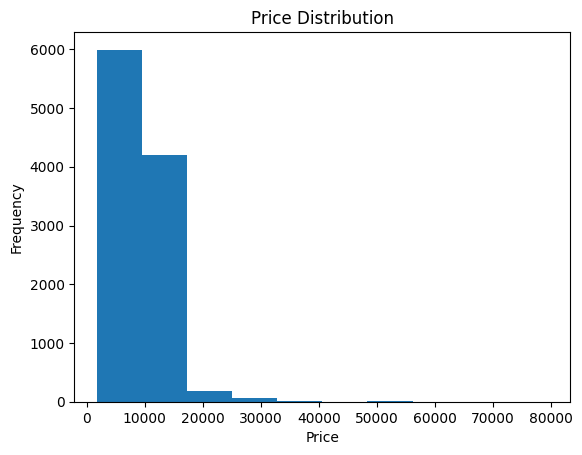

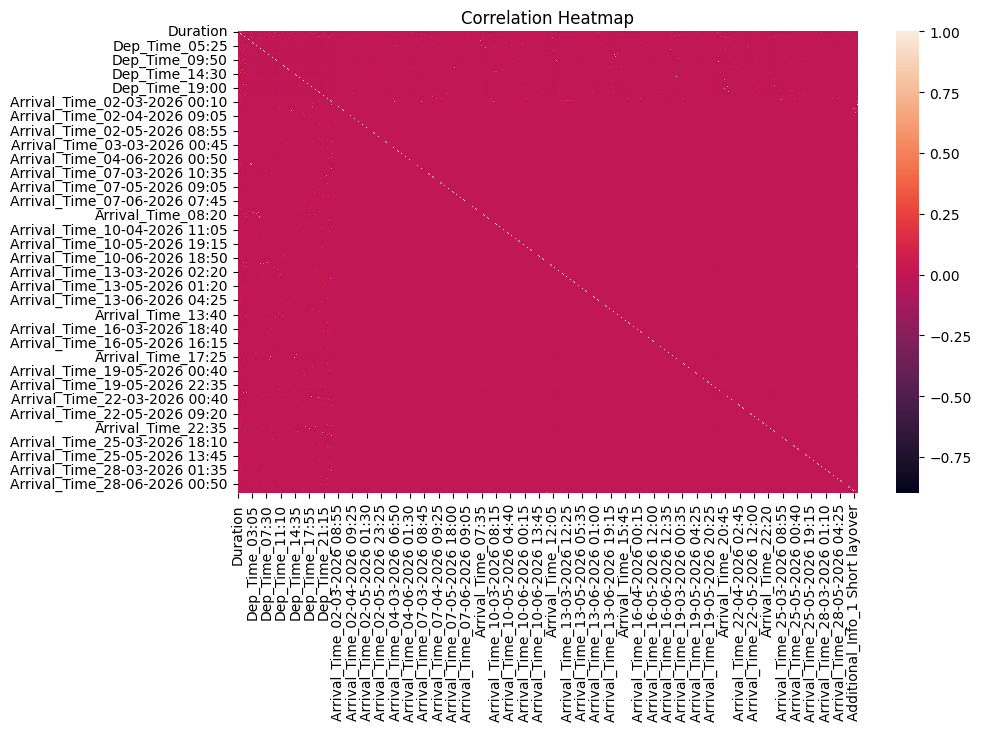


Top 10 Highest Prices:
 2924     79512
5372     62427
10364    57209
5439     54826
1478     54826
2618     54826
9715     52285
657      52229
7351     46490
396      36983
Name: Price, dtype: int64


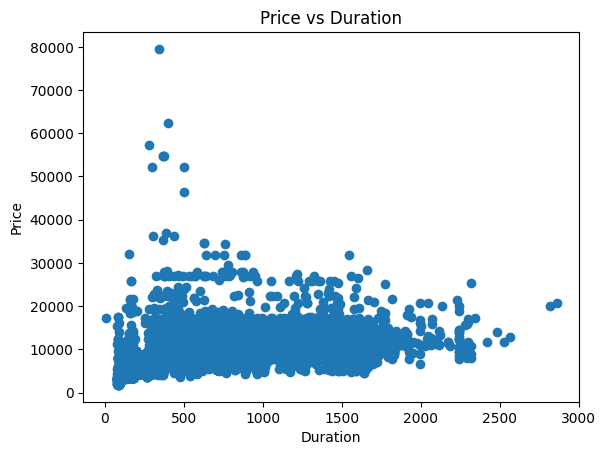

In [16]:
# ===============================
# 4. Exploratory Data Analysis (EDA)
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# Basic statistical summary
print("Statistical Summary:\n")
print(df.describe())

# -------------------------------
# Univariate Analysis
# -------------------------------

# Price Distribution
plt.figure()
plt.hist(df['Price'])
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# Multivariate Analysis
# -------------------------------

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr())
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# Additional Analysis
# -------------------------------

# Top 10 highest prices
print("\nTop 10 Highest Prices:\n", df['Price'].sort_values(ascending=False).head(10))

# Price vs Duration (if duration exists)
if 'Duration' in df.columns:
    plt.figure()
    plt.scatter(df['Duration'], df['Price'])
    plt.title("Price vs Duration")
    plt.xlabel("Duration")
    plt.ylabel("Price")
    plt.show()

**5. Data Visualization (Static)**

Data visualization is used to represent data graphically, making it easier to understand patterns, trends, and relationships.
Static visualizations are fixed images that help in summarizing the dataset effectively.

In this step, various plots such as bar charts, histograms, box plots, and heatmaps are created using Python libraries like Matplotlib and Seaborn.
These visualizations help in identifying distribution, detecting outliers, and understanding relationships between variables.

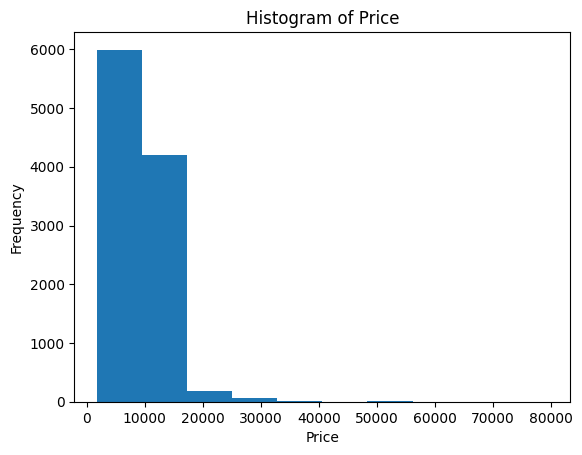

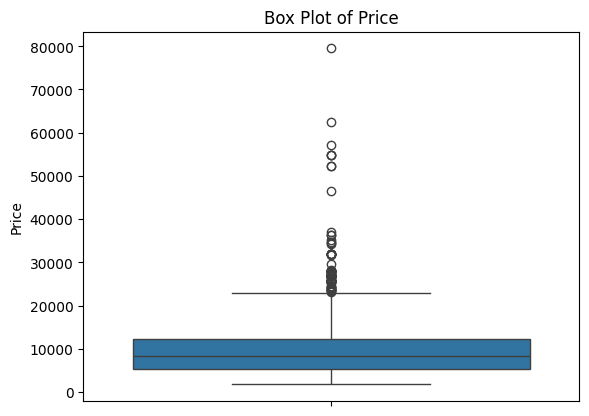

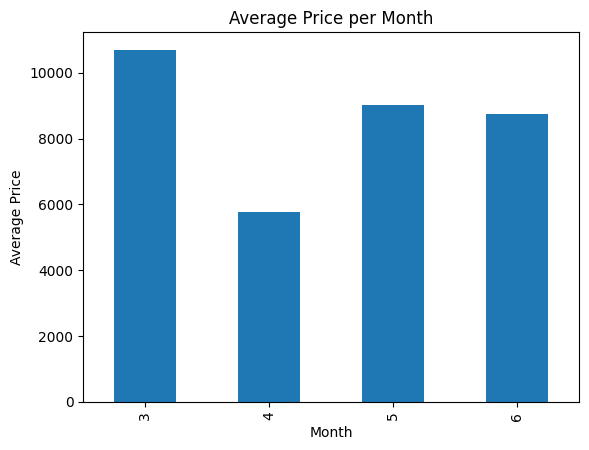

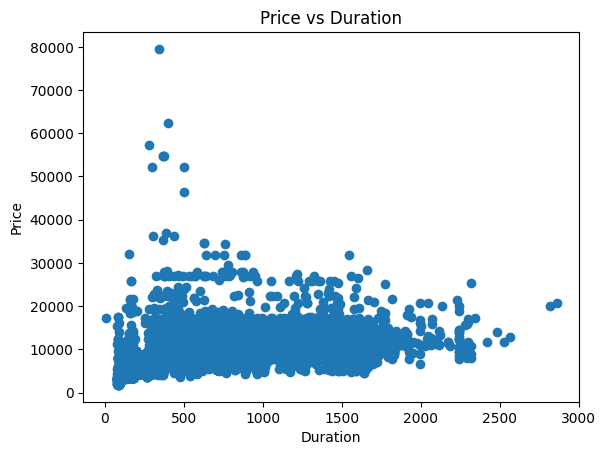

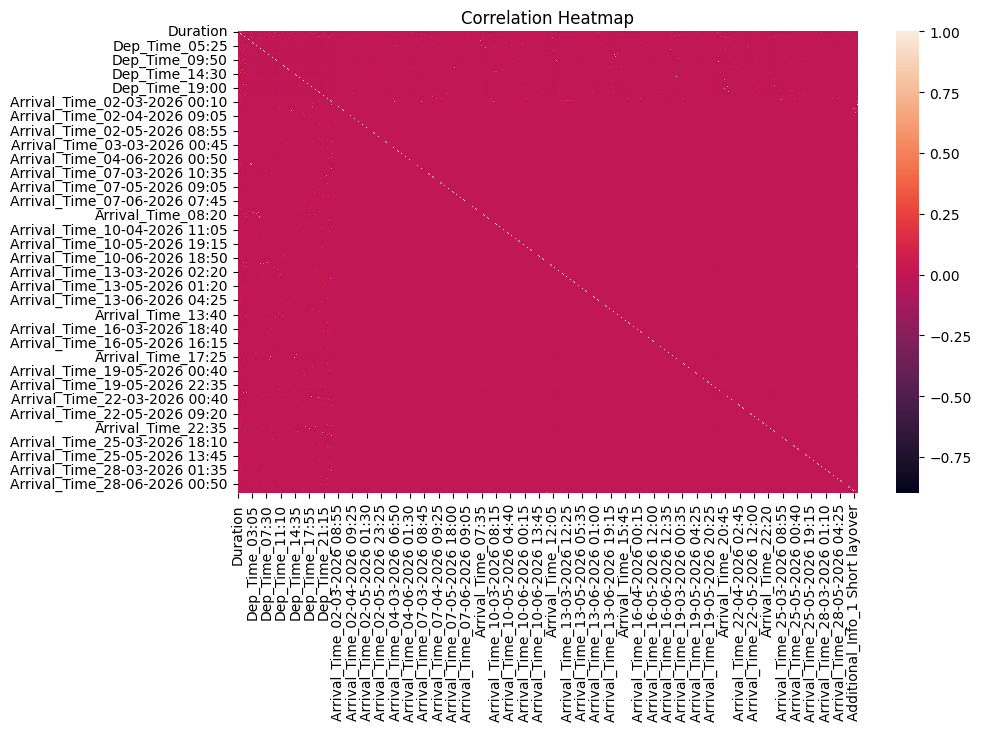

In [17]:
# ===============================
# 5. Data Visualization (Static)
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Histogram (Price Distribution)
# -------------------------------
plt.figure()
plt.hist(df['Price'])
plt.title("Histogram of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# 2. Box Plot (Outliers Detection)
# -------------------------------
plt.figure()
sns.boxplot(y=df['Price'])
plt.title("Box Plot of Price")
plt.show()

# -------------------------------
# 3. Bar Plot (Average Price per Month)
# -------------------------------
if 'Journey_month' in df.columns:
    plt.figure()
    df.groupby('Journey_month')['Price'].mean().plot(kind='bar')
    plt.title("Average Price per Month")
    plt.xlabel("Month")
    plt.ylabel("Average Price")
    plt.show()

# -------------------------------
# 4. Scatter Plot (Price vs Duration)
# -------------------------------
if 'Duration' in df.columns:
    plt.figure()
    plt.scatter(df['Duration'], df['Price'])
    plt.title("Price vs Duration")
    plt.xlabel("Duration")
    plt.ylabel("Price")
    plt.show()

# -------------------------------
# 5. Heatmap (Correlation)
# -------------------------------
plt.figure(figsize=(10,6))
sns.heatmap(df.corr())
plt.title("Correlation Heatmap")
plt.show()

**6. Interactive Visualization & Dashboards**

Interactive visualizations allow users to explore data dynamically by zooming, hovering, and filtering information.
Unlike static plots, interactive charts provide better insights and improve user experience.

In this step, interactive visualizations are created using the Plotly library.
These visualizations help in understanding relationships between variables such as price, duration, and journey month.
Interactive dashboards can be further developed using tools like Tableau or Power BI for better presentation and decision-making.

In [18]:
# ===============================
# 6. Interactive Visualization & Dashboards
# ===============================

import plotly.express as px

# -------------------------------
# 1. Interactive Scatter Plot
# -------------------------------
if 'Duration' in df.columns:
    fig = px.scatter(df, x='Duration', y='Price',
                     title="Interactive: Price vs Duration")
    fig.show()

# -------------------------------
# 2. Interactive Bar Chart
# -------------------------------
if 'Journey_month' in df.columns:
    avg_price = df.groupby('Journey_month')['Price'].mean().reset_index()

    fig = px.bar(avg_price, x='Journey_month', y='Price',
                 title="Average Price per Month")
    fig.show()

# -------------------------------
# 3. Interactive Histogram
# -------------------------------
fig = px.histogram(df, x='Price',
                   title="Interactive Price Distribution")
fig.show()

**7. Regression Models**

Regression models are used to predict continuous numerical values based on input features.
In this project, regression is used to predict flight ticket prices using various factors such as duration, airline, and journey details.

Linear Regression is one of the simplest and most widely used regression techniques.
It establishes a linear relationship between independent variables and the target variable.

The model is trained on a portion of the dataset and evaluated using metrics such as Mean Absolute Error (MAE) and R-squared (R²) score to measure performance.

In [19]:
# ===============================
# 7. Regression Models
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Separate features and target
X = df.drop('Price', axis=1)
y = df['Price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 1671.488538799759
R2 Score: 0.5304072707190941


** 8. Classification Models**

Classification models are used to predict categorical outcomes.
In this project, the continuous price variable is converted into categories such as high and low price.

A threshold value is used to divide the dataset into classes.
Machine learning algorithms like Decision Tree and Random Forest are used to classify the data.

These models are evaluated using accuracy to determine how well they can correctly classify flight prices.

In [20]:
# ===============================
# 8. Classification Models
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Convert Price into categories (0 = Low, 1 = High)
threshold = df['Price'].median()
df['Price_Category'] = df['Price'].apply(lambda x: 1 if x > threshold else 0)

# Features and target
X_cls = df.drop(['Price', 'Price_Category'], axis=1)
y_cls = df['Price_Category']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

# -------------------------------
# Decision Tree Model
# -------------------------------
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

dt_acc = dt_model.score(X_test, y_test)
print("Decision Tree Accuracy:", dt_acc)

# -------------------------------
# Random Forest Model
# -------------------------------
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_acc = rf_model.score(X_test, y_test)
print("Random Forest Accuracy:", rf_acc)

Decision Tree Accuracy: 0.945054945054945
Random Forest Accuracy: 0.9498327759197325


** 9. Clustering Techniques**

Clustering is an unsupervised machine learning technique used to group similar data points together based on their characteristics.
Unlike supervised learning, clustering does not require labeled data.

In this project, K-Means clustering is applied to group flight data into different clusters based on features such as price and duration.
These clusters help in identifying patterns like low-cost, medium-cost, and high-cost flights.

Clustering helps in understanding the structure of the data and discovering hidden patterns.

In [21]:
# ===============================
# 9. Clustering Techniques
# ===============================

from sklearn.cluster import KMeans

# Use features only (exclude target if needed)
X_cluster = df.drop(['Price'], axis=1)

# OPTIONAL: use scaled data for better clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled_cluster = scaler.fit_transform(X_cluster)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled_cluster)

# Add cluster labels to dataset
df['Cluster'] = clusters

print("Cluster labels added!")
print(df[['Cluster']].head())

Cluster labels added!
   Cluster
0        0
1        0
2        0
3        0
4        0


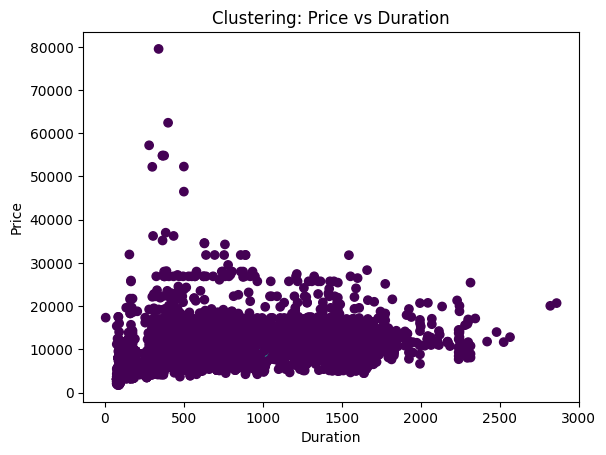

In [22]:
import matplotlib.pyplot as plt

# Plot clusters (using Duration if available)
if 'Duration' in df.columns:
    plt.figure()
    plt.scatter(df['Duration'], df['Price'], c=df['Cluster'])
    plt.title("Clustering: Price vs Duration")
    plt.xlabel("Duration")
    plt.ylabel("Price")
    plt.show()

 **10. Capstone Mini Project**

The capstone project integrates all the steps of the data science process to build a complete solution.
The objective of this project is to analyze flight data and predict ticket prices using machine learning techniques.

The process includes data collection, data cleaning, feature engineering, exploratory data analysis, visualization, and model building.
Both regression and classification models are implemented, and clustering techniques are used to identify patterns in the dataset.

The models are evaluated using appropriate metrics, and insights are derived from the analysis.
This end-to-end workflow demonstrates the practical application of data science concepts in solving real-world problems.

In [24]:
# ===============================
# 10. Capstone Mini Project
# ===============================

print("===== FINAL PROJECT SUMMARY =====")

# Dataset info
print("\nDataset Shape:", df.shape)

# Regression Results
print("\n--- Regression Model ---")
print("Model Used: Linear Regression")
print("MAE:", mae)
print("R2 Score:", r2)

# Classification Results
print("\n--- Classification Models ---")
print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)

# Clustering Info
print("\n--- Clustering ---")
print("Number of Clusters:", len(df['Cluster'].unique()))

# Final Conclusion
print("\n===== CONCLUSION =====")
print("Flight price prediction was successfully performed using machine learning models.")
print("Regression, classification, and clustering techniques were applied.")
print("The project demonstrates end-to-end data science workflow.")

===== FINAL PROJECT SUMMARY =====

Dataset Shape: (10463, 1602)

--- Regression Model ---
Model Used: Linear Regression
MAE: 1671.488538799759
R2 Score: 0.5304072707190941

--- Classification Models ---
Decision Tree Accuracy: 0.945054945054945
Random Forest Accuracy: 0.9498327759197325

--- Clustering ---
Number of Clusters: 3

===== CONCLUSION =====
Flight price prediction was successfully performed using machine learning models.
Regression, classification, and clustering techniques were applied.
The project demonstrates end-to-end data science workflow.


The project successfully analyzed flight data and predicted ticket prices
Linear Regression was used for price prediction
Classification models categorized flights into price groups
K-Means clustering identified patterns in pricing
The workflow covered complete data science pipeline
The results show that machine learning can effectively predict flight prices